In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

sys.path.insert(1,'../')

from VI_solvers.rad_vi import RadVI 
from VI_solvers.laplace_approx import laplace_from_potential
from VI_solvers.gaussian_fbvi import Gaussian_FBVI

from utils.plotting import plot_radial_sortings, plot_2dim_scatter
from utils.elliptical_distributions import MultivariateGaussian, MultivariateLaplace, MultivariateStudent, MultivariateLogistic 

In [2]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({"font.family": "serif", "font.serif": "Computer Modern"})
np.random.seed(2)

if not os.path.exists('plots/anisotropic'):
    os.makedirs('plots/anisotropic')

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [3]:
### Define target distribution parameters
dim = 50

target_mean = np.zeros((dim, 1))
cov_ = np.random.randn(dim, dim)
target_cov  = cov_ @ cov_.T + np.eye(dim)
target_dof  = 10 # For Student-t distribution
target_scale = 1 # For Logistic distribution

## Laplace distribution

In [4]:
### Define distribution
target_distribution = MultivariateLaplace(target_mean, target_cov)
V_laplace           = lambda x: target_distribution.potential(x)
gradV_laplace       = lambda x: target_distribution.grad_potential(x)
hessV_laplace       = lambda x: target_distribution.hess_potential(x)

In [5]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 7e-3
n_iterations   = 5000 * 6
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [6]:
### Fit Laplace approximation
mean_laplace_approx_laplace, cov_laplace_approx_laplace = laplace_from_potential(V=V_laplace, 
                                                                                 grad_V=gradV_laplace, 
                                                                                 x0=np.ones(dim),
                                                                                 method='Powell')

### Initialize and fit radVI model with Laplace approximation of mean and covariance
RadVI_laplace_laplace = RadVI(truncation=truncation, 
                              mesh=mesh, 
                              dim=dim, 
                              alpha=alpha, 
                              isotropic=False,
                              V=V_laplace,
                              grad_V=gradV_laplace, 
                              mean=mean_laplace_approx_laplace, 
                              covariance=cov_laplace_approx_laplace,
                              N_mc=n_samples_mc)

RadVI_laplace_laplace.fit(learning_rate=learning_rate,
                          num_iterations=n_iterations, 
                          sample_size=n_samples_sgd,
                          print_freq=5000)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting radVI approximation.



In [7]:
### Fit Gaussian VI
gaussian_fbvi = Gaussian_FBVI(learning_rate=learning_rate,
                              dim=dim,
                              grad_V=gradV_laplace,
                              hess_V=hessV_laplace,
                              mean=np.zeros((dim, 1)),
                              covariance=np.eye(dim))

gaussian_fbvi.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=5000)

mean_fbvi_laplace    = gaussian_fbvi.mean
cov_fbvi_laplace     = gaussian_fbvi.sigma

### Initialize and fit radVI model with Gaussian VI approximation of mean and covariance
RadVI_laplace_fbvi = RadVI(truncation=truncation,
                           mesh=mesh, 
                           dim=dim, 
                           alpha=alpha, 
                           isotropic=False,
                           V=V_laplace,
                           grad_V=gradV_laplace, 
                           mean=mean_fbvi_laplace, 
                           covariance=cov_fbvi_laplace,
                           N_mc=n_samples_mc)

RadVI_laplace_fbvi.fit(learning_rate=learning_rate,
                       num_iterations=n_iterations, 
                       sample_size=n_samples_sgd,
                       print_freq=5000)


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 3000

/var/folders/_2/kk0m1klx7vjdmxtw2ms6f8400000gn/T/ipykernel_16063/2655593681.py:2: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_laplace.flatten(), cov=cov_laplace_approx_laplace, size=n_samples_plot).T


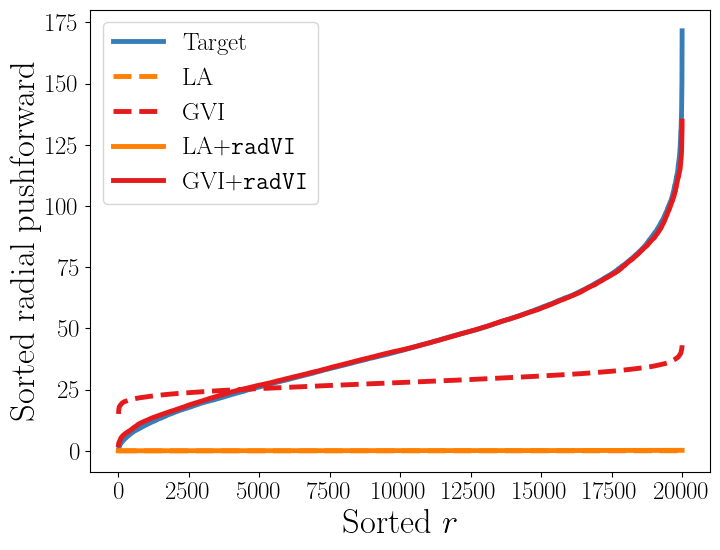

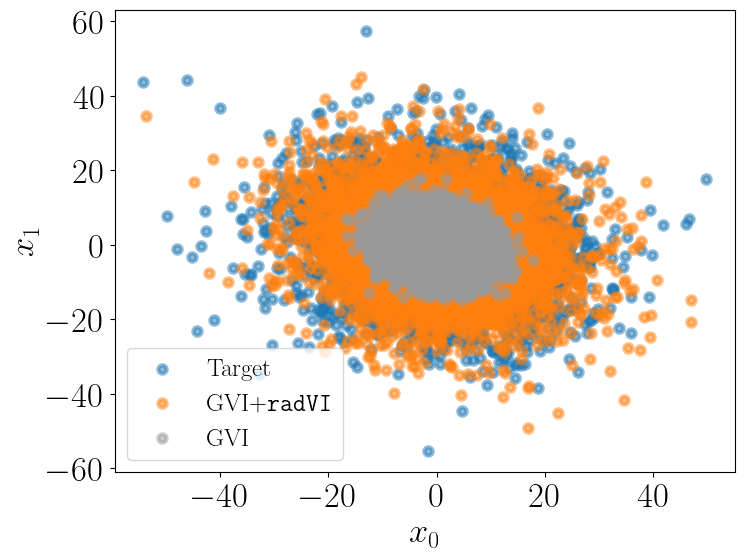

In [ ]:
### Generate Laplace approximation samples
laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_laplace.flatten(), cov=cov_laplace_approx_laplace, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Laplace approximation
source_data         = np.random.randn(dim, n_samples_plot)
pushforward_laplace = RadVI_laplace_laplace.push_forward(source_data)

### Generate Gaussian VI approximation samples
fbvi_data = np.random.multivariate_normal(mean=mean_fbvi_laplace.flatten(), cov=cov_fbvi_laplace, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Gaussian VI approximation
pushforward_fbvi = RadVI_laplace_fbvi.push_forward(source_data)

### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

### compute radial diagnostics
r_target              = np.linalg.norm(target_data, axis=0)
r_pushforward_fbvi    = np.linalg.norm(pushforward_fbvi, axis=0)
r_pushforward_laplace = np.linalg.norm(pushforward_laplace, axis=0)
r_fbvi                = np.linalg.norm(fbvi_data, axis=0)
r_laplace             = np.linalg.norm(laplace_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "-", "color": CB_color_cycle[0]},
                      {"data": r_laplace, "label": "LA", "linestyle": "dashed", "color": CB_color_cycle[1]},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "dashed", "color": CB_color_cycle[-2]}, 
                      {"data": r_pushforward_laplace, "label": r"LA$+\texttt{radVI}$", "color": CB_color_cycle[1]},
                      {"data": r_pushforward_fbvi, "label": r"GVI$+\texttt{radVI}$", "color": CB_color_cycle[-2]}],
                      type="anisotropic",
                      save_path=f'plots/anisotropic/anisotropic_laplace_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_fbvi, "label": r"GVI$+\texttt{radVI}$"},
                   {"data": fbvi_data, "label": "GVI", "color": "#999999"}],
                   save_path=f'plots/anisotropic/anisotropic_laplace_scatter_dim{dim}.pdf')

## Logistic

In [9]:
### Define distribution
target_distribution = MultivariateLogistic(target_mean, target_cov, target_scale)
V_logistic          = lambda x: target_distribution.potential(x)
gradV_logistic      = lambda x: target_distribution.grad_potential(x)
hessV_logistic      = lambda x: target_distribution.hess_potential(x)

In [10]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 7e-3
n_iterations   = 5000 * 6
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [11]:
### Fit Laplace approximation
mean_laplace_approx_logistic, cov_laplace_approx_logistic = laplace_from_potential(V=V_logistic, 
                                                                                   grad_V=gradV_logistic, 
                                                                                   x0=np.ones(dim),
                                                                                   method='Powell')

### Initialize and fit radVI model with Laplace approximation of mean and covariance
RadVI_logistic_laplace = RadVI(truncation=truncation, 
                               mesh=mesh, 
                               dim=dim, 
                               alpha=alpha, 
                               isotropic=False,
                               V=V_logistic,
                               grad_V=gradV_logistic, 
                               mean=mean_laplace_approx_logistic, 
                               covariance=cov_laplace_approx_logistic,
                               N_mc=n_samples_mc)

RadVI_logistic_laplace.fit(learning_rate=learning_rate,
                           num_iterations=n_iterations, 
                           sample_size=n_samples_sgd,
                           print_freq=5000)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting radVI approximation.



In [12]:
### Fit Gaussian VI
gaussian_fbvi = Gaussian_FBVI(learning_rate=learning_rate,
                              dim=dim,
                              grad_V=gradV_logistic,
                              hess_V=hessV_logistic,
                              mean=np.zeros((dim, 1)),
                              covariance=np.eye(dim))

gaussian_fbvi.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=5000)

mean_fbvi_logistic    = gaussian_fbvi.mean
cov_fbvi_logistic     = gaussian_fbvi.sigma

### Initialize and fit radVI model with Gaussian VI approximation of mean and covariance
RadVI_logistic_fbvi = RadVI(truncation=truncation,
                            mesh=mesh, 
                            dim=dim, 
                            alpha=alpha, 
                            isotropic=False,
                            V=V_logistic,
                            grad_V=gradV_logistic, 
                            mean=mean_fbvi_logistic, 
                            covariance=cov_fbvi_logistic,
                            N_mc=n_samples_mc)

RadVI_logistic_fbvi.fit(learning_rate=learning_rate,
                        num_iterations=n_iterations, 
                        sample_size=n_samples_sgd,
                        print_freq=5000)


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 3000

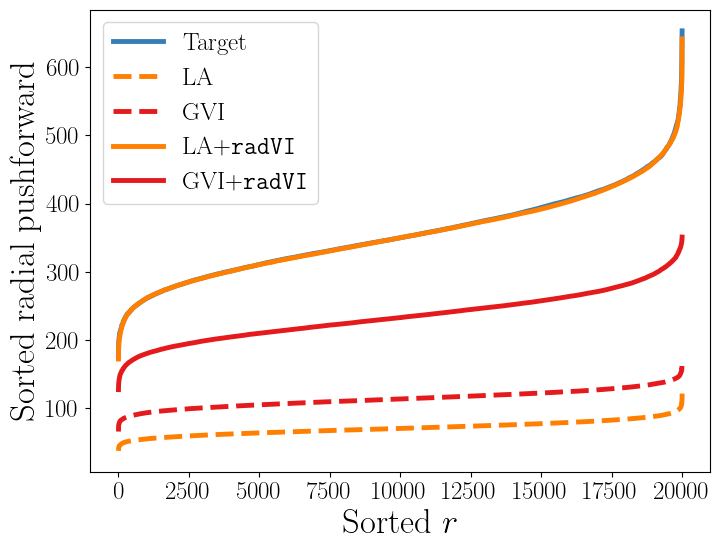

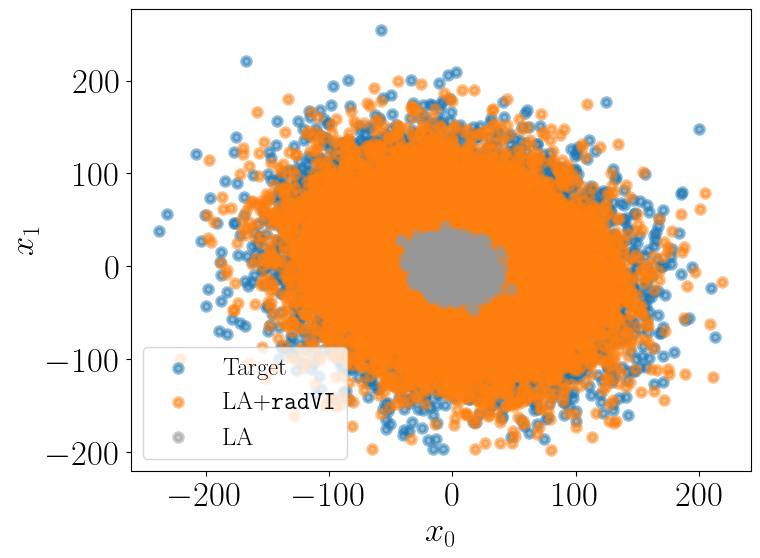

In [ ]:
### Generate Laplace approximation samples
laplace_data  = np.random.multivariate_normal(mean=mean_laplace_approx_logistic.flatten(), cov=cov_laplace_approx_logistic, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Laplace approximation
source_data         = np.random.randn(dim, n_samples_plot)
pushforward_laplace = RadVI_logistic_laplace.push_forward(source_data)

### Generate Gaussian VI approximation samples    
gaussian_data = np.random.multivariate_normal(mean=mean_fbvi_logistic.flatten(), cov=cov_fbvi_logistic, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Gaussian VI approximation
pushforward_fbvi    = RadVI_logistic_fbvi.push_forward(source_data)

### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)
                  
### compute radial diagnostics
r_target              = np.linalg.norm(target_data, axis=0)
r_pushforward_fbvi    = np.linalg.norm(pushforward_fbvi, axis=0)
r_pushforward_laplace = np.linalg.norm(pushforward_laplace, axis=0)
r_fbvi                = np.linalg.norm(gaussian_data, axis=0)
r_laplace             = np.linalg.norm(laplace_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "-", "color": CB_color_cycle[0]},
                      {"data": r_laplace, "label": "LA", "linestyle": "dashed", "color": CB_color_cycle[1]},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "dashed", "color": CB_color_cycle[-2]}, 
                      {"data": r_pushforward_laplace, "label": r"LA$+\texttt{radVI}$", "color": CB_color_cycle[1]},
                      {"data": r_pushforward_fbvi, "label": r"GVI$+\texttt{radVI}$", "color": CB_color_cycle[-2]}],
                      type="anisotropic",
                      save_path=f'plots/anisotropic/anisotropic_logistic_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_laplace, "label": r"LA$+\texttt{radVI}$"},
                   {"data": laplace_data, "label": "LA", "color": "#999999"}],
                   save_path=f'plots/anisotropic/anisotropic_logistic_scatter_dim{dim}.pdf')

## Student-t distribution

In [14]:
### Define distribution
target_distribution = MultivariateStudent(target_mean, target_cov, target_dof)
V_student           = lambda x: target_distribution.potential(x)
gradV_student       = lambda x: target_distribution.grad_potential(x)
hessV_student       = lambda x: target_distribution.hess_potential(x)

In [15]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 7e-3
n_iterations   = 5000 * 6
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [16]:
### Fit Laplace approximation
mean_laplace_approx_student, cov_laplace_approx_student = laplace_from_potential(V=V_student, 
                                                                                 grad_V=gradV_student, 
                                                                                 x0=np.ones(dim),
                                                                                 method='Powell')

### Initialize and fit radVI model with Laplace approximation of mean and covariance
RadVI_student_laplace = RadVI(truncation=truncation, 
                              mesh=mesh, 
                              dim=dim, 
                              alpha=alpha, 
                              isotropic=False,
                              V=V_student,
                              grad_V=gradV_student, 
                              mean=mean_laplace_approx_student, 
                              covariance=cov_laplace_approx_student,
                              N_mc=n_samples_mc)

RadVI_student_laplace.fit(learning_rate=learning_rate,
                          num_iterations=n_iterations, 
                          sample_size=n_samples_sgd,
                          print_freq=5000)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting radVI approximation.



In [17]:
### Fit Gaussian VI
gaussian_fbvi = Gaussian_FBVI(learning_rate=learning_rate,
                              dim=dim,
                              grad_V=gradV_student,
                              hess_V=hessV_student,
                              mean=np.zeros((dim, 1)),
                              covariance=np.eye(dim))

gaussian_fbvi.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=5000)

mean_fbvi_student = gaussian_fbvi.mean
cov_fbvi_student  = gaussian_fbvi.sigma 

### Initialize and fit radVI model with Gaussian FBVI approximation of mean and covariance
RadVI_student_fbvi = RadVI(truncation=truncation, 
                           mesh=mesh, 
                           dim=dim, 
                           alpha=alpha, 
                           isotropic=False,
                           V=V_student,
                           grad_V=gradV_student, 
                           mean=mean_fbvi_student, 
                           covariance=cov_fbvi_student,
                           N_mc=n_samples_mc)

RadVI_student_fbvi.fit(learning_rate=learning_rate*2,
                       num_iterations=n_iterations, 
                       sample_size=n_samples_sgd,
                       print_freq=5000)


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 30000
Iteration 20000 of 30000
Iteration 25000 of 30000
Iteration 30000 of 30000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.014
• Iterations      : 30000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 30000
Iteration 10000 of 30000
Iteration 15000 of 3000

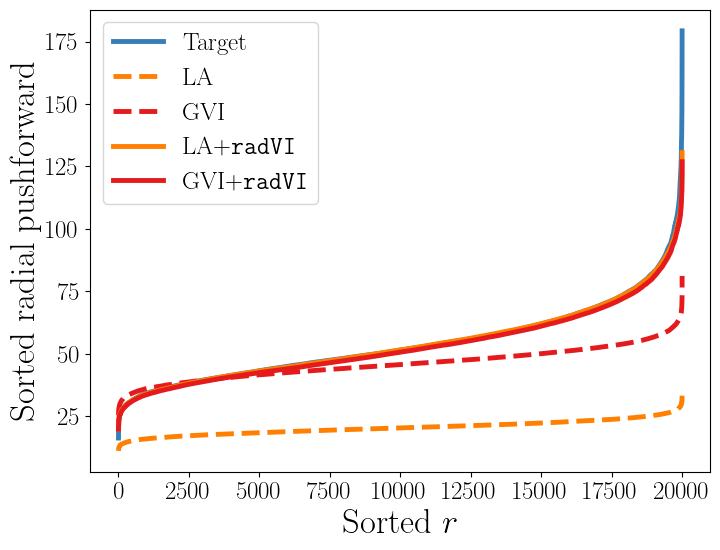

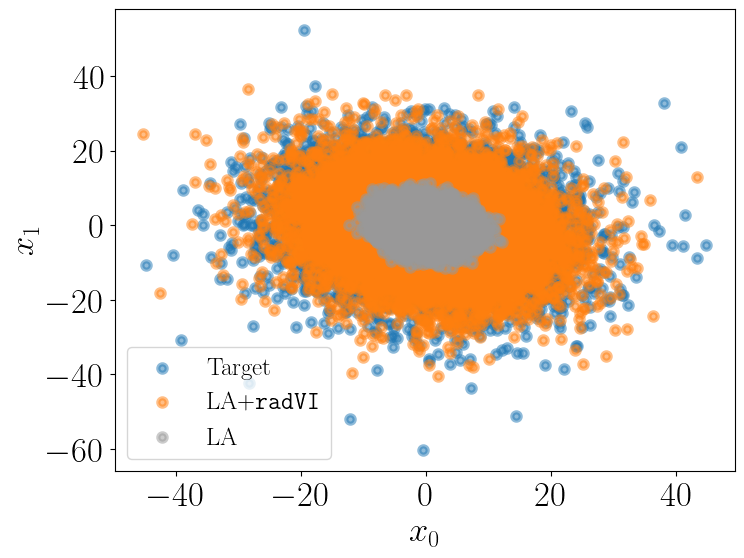

In [ ]:
### Generate Laplace approximation samples
laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_student.flatten(), cov=cov_laplace_approx_student, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Laplace approximation
source_data         = np.random.randn(dim, n_samples_plot)
pushforward_laplace = RadVI_student_laplace.push_forward(source_data)

### Generate Gaussian VI approximation samples
fbvi_data = np.random.multivariate_normal(mean=mean_fbvi_student.flatten(), cov=cov_fbvi_student, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Gaussian VI approximation
pushforward_fbvi = RadVI_student_fbvi.push_forward(source_data)

### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

### Compute radial diagnostics
r_pushforward_laplace = np.linalg.norm(pushforward_laplace, axis=0)
r_pushforward_fbvi    = np.linalg.norm(pushforward_fbvi, axis=0)
r_target              = np.linalg.norm(target_data, axis=0)
r_laplace             = np.linalg.norm(laplace_data, axis=0)
r_fbvi                = np.linalg.norm(fbvi_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "-", "color": CB_color_cycle[0]},
                      {"data": r_laplace, "label": "LA", "linestyle": "dashed", "color": CB_color_cycle[1]},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "dashed", "color": CB_color_cycle[-2]}, 
                      {"data": r_pushforward_laplace, "label": r"LA$+\texttt{radVI}$", "color": CB_color_cycle[1]},
                      {"data": r_pushforward_fbvi, "label": r"GVI$+\texttt{radVI}$", "color": CB_color_cycle[-2]}],
                      type="anisotropic",
                      save_path=f'plots/anisotropic/anisotropic_student_dof_{int(target_distribution.dof)}_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_laplace, "label": r"LA$+\texttt{radVI}$"},
                   {"data": laplace_data, "label": "LA", "color": "#999999"}],
                   save_path=f'plots/anisotropic/anisotropic_student_dof_{int(target_distribution.dof)}_scatter_dim{dim}.pdf')